Since the backbone has been frozen in our approach, users can conveniently acquire the pre-trained weights from [facebookresearch](https://dl.fbaipublicfiles.com/dinov2/dinov2_vitl14/dinov2_vitl14_pretrain.pth). With these weights, users can effortlessly generate the complete model weights using `dinov2_rein_and_head.pth`.

In [5]:
! python tools/convert_models/convert_dinov2.py checkpoints/dinov2_vitl14_pretrain.pth checkpoints/dinov2_converted.pth

  File "tools/convert_models/convert_dinov2.py", line 24
    f"{pretrained_path} dont exist(absolute path: {osp.abspath(pretrained_path)})"
                                                                                 ^
SyntaxError: invalid syntax


In [1]:
# import and init
import torch
import torch.nn as nn
import rein
from rein.utils import init_model
from mmengine.config import Config
from mmseg.apis.inference import inference_model,show_result_pyplot
import matplotlib.pyplot as plt
cfg=Config.fromfile('/data3/qinghua/qinghua_before/ZDJ/code/Rein_SAM/configs/dinov2/rein_dinov2_mask2former_512x512_bs1x4.py')
network:nn.Module=init_model(cfg,dict(backbone='/data3/qinghua/qinghua_before/ZDJ/code/Rein_SAM/checkpoints/dinov2_converted.pth',rein_head='/data3/qinghua/qinghua_before/ZDJ/code/Rein_SAM/output_dir/dinov2/method1_2/g2cbm64_512/iter_32000.pth'),'cuda:0')
network.cfg=cfg
network.cfg.test_pipeline=network.cfg.bdd_test_pipeline
torch.set_grad_enabled(False)

/data3/qinghua/qinghua_before/ZDJ/code/Rein_SAM/rein/models/backbones/dino_layers/swiglu_ffn.py:43: UserWarning: xFormers is available (SwiGLU)
  warnings.warn("xFormers is available (SwiGLU)")
/data3/qinghua/qinghua_before/ZDJ/code/Rein_SAM/rein/models/backbones/dino_layers/attention.py:27: UserWarning: xFormers is available (Attention)
  warnings.warn("xFormers is available (Attention)")
/data3/qinghua/qinghua_before/ZDJ/code/Rein_SAM/rein/models/backbones/dino_layers/block.py:33: UserWarning: xFormers is available (Block)
  warnings.warn("xFormers is available (Block)")
/data1/qinghua/SEU/envs/rein/lib/python3.9/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


Fail to import ReinsConvNeXt, if you need to use it, please install mmpretrain
Loads checkpoint by local backend from path: /data3/qinghua/qinghua_before/ZDJ/code/Rein_SAM/checkpoints/dinov2_converted.pth


/data1/qinghua/SEU/envs/rein/lib/python3.9/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3483.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
/data1/qinghua/SEU/envs/rein/lib/python3.9/site-packages/mmengine/visualization/visualizer.py:196: UserWarning: Failed to add <class 'mmengine.visualization.vis_backend.LocalVisBackend'>, please provide the `save_dir` argument.
  warnings.warn(f'Failed to add {vis_backend.__class__}, '


(-0.5, 2047.5, 1023.5, -0.5)

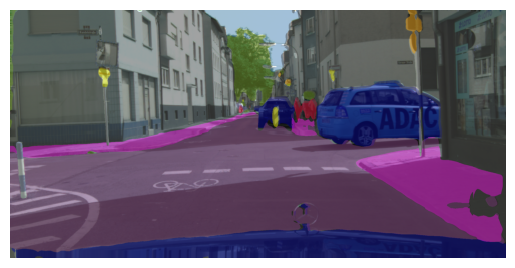

In [2]:
im_path='docs/nightbdd.jpg'
result=inference_model(network,im_path)
vis_img=show_result_pyplot(network,im_path,result)
plt.imshow(vis_img)
plt.axis('off')

Even without accessing any real urban-scene datasets, we still generated impressive segmentation effects in real cities.

(-0.5, 1279.5, 719.5, -0.5)

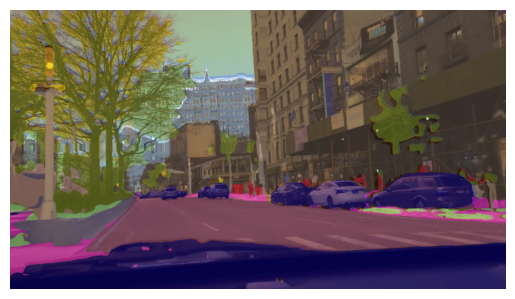

In [3]:
im_path='docs/citys1.png'
result=inference_model(network,im_path)
vis_img=show_result_pyplot(network,im_path,result)
plt.imshow(vis_img)
plt.axis('off')

(-0.5, 3263.5, 2447.5, -0.5)

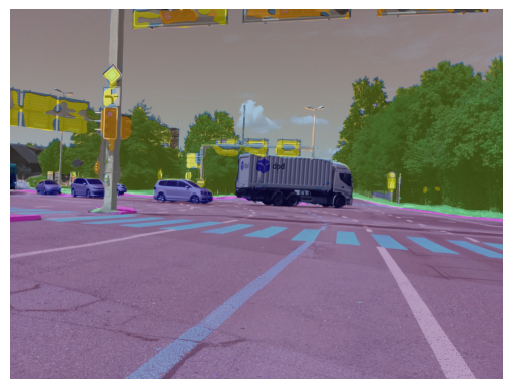

In [4]:
im_path='docs/citys2.png'
result=inference_model(network,im_path)
vis_img=show_result_pyplot(network,im_path,result)
plt.imshow(vis_img)
plt.axis('off')